
# 作業 3：分類模型入門 — 以 Adult Income 資料集預測收入類別

這份作業是根據上課教材 `3.ipynb` 簡化而成，目標是讓同學用比較少、比較清楚的程式碼，練習分類問題的完整流程。

本作業會使用 `adult.csv`，預測一個人的收入是否大於 50K。

目標變數：

- `income = <=50K`：收入不超過 50K
- `income = >50K`：收入大於 50K

本作業保留教材中的主要知識點，但每一類方法只選一個代表做法：

1. 讀取與檢查資料
2. 建立分類目標變數
3. 類別型特徵轉換
4. 切分訓練集與測試集
5. 特徵標準化
6. 羅吉斯迴歸分類模型
7. sigmoid 函數與預測機率
8. 分類結果評估：本作業只使用 **F1-score** 作為主要指標
9. 混淆矩陣視覺化
10. 交叉驗證
11. 正則化參數 `C`
12. 分類結果可靠度：`predict_proba()` 與 `decision_function()`
13. 特徵重要性與簡化版特徵選擇
14. 補充說明：SVM、Naive Bayes、Decision Tree、Random Forest、KNN 的核心概念

限制：

- 不使用 `Pipeline`
- 不使用 list comprehension
- 程式碼以初學者容易閱讀為主



## 1. 匯入套件與基本設定

這一段會載入本作業需要用到的 Python 套件。

`matplotlib` 用來畫圖；`pandas` 用來處理表格資料；`scikit-learn` 用來建立分類模型。


In [1]:

# 忽略部分警告訊息，讓畫面比較乾淨
import warnings
warnings.filterwarnings("ignore")

# 資料處理
import numpy as np
import pandas as pd

# 視覺化
import matplotlib.pyplot as plt

# 資料切分與交叉驗證
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold

# 特徵標準化
from sklearn.preprocessing import StandardScaler

# 分類模型
from sklearn.linear_model import LogisticRegression

# 評估工具
from sklearn.metrics import f1_score
from sklearn.metrics import ConfusionMatrixDisplay

# 設定 pandas 顯示方式
pd.set_option("display.max_columns", 100)

# 設定中文字型
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",
    "Microsoft YaHei",
    "SimHei",
    "Arial Unicode MS",
    "DejaVu Sans"
]
plt.rcParams["axes.unicode_minus"] = False



## 2. 讀取資料集

請確認 `adult.csv` 與這份 Notebook 放在同一個資料夾。

讀取後，先檢查：

- 資料有幾列、幾欄
- 前幾筆資料長什麼樣子
- 目標欄位 `income` 有哪些類別


In [2]:

# 讀取 Adult Income 資料集
# 這是一個常見的二元分類資料集
# 任務是預測收入是否大於 50K

df = pd.read_csv("adult.csv")

print("資料筆數與欄位數：")
print(df.shape)

print("\n前 5 筆資料：")
display(df.head())

print("\nincome 類別分布：")
print(df["income"].value_counts())


資料筆數與欄位數：
(48842, 15)

前 5 筆資料：


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K



income 類別分布：
income
<=50K    37155
>50K     11687
Name: count, dtype: int64



## 3. 資料清理與目標變數建立

Adult 資料集中的部分欄位會用 `?` 表示未知值。

在這份作業中，為了簡化教學流程，我們直接把 `?` 當成缺失值，並刪除含有缺失值的資料列。

接著建立新的目標欄位：

- `income_label = 0`：收入 `<=50K`
- `income_label = 1`：收入 `>50K`


In [3]:

# 複製一份資料，避免直接修改原始 df

df_clean = df.copy()

# 將 ? 取代成 NaN，方便 pandas 辨識缺失值
df_clean = df_clean.replace("?", np.nan)

print("各欄位缺失值數量：")
print(df_clean.isna().sum())

# 為了讓作業簡化，這裡直接刪除含有缺失值的列
df_clean = df_clean.dropna()
df_clean = df_clean.reset_index(drop=True)

# 建立二元分類標籤
# <=50K 設為 0，>50K 設為 1
df_clean["income_label"] = df_clean["income"].map({"<=50K": 0, ">50K": 1})

print("\n清理後資料筆數與欄位數：")
print(df_clean.shape)

print("\n目標變數分布：")
print(df_clean["income_label"].value_counts())


各欄位缺失值數量：
age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

清理後資料筆數與欄位數：
(45222, 16)

目標變數分布：
income_label
0    34014
1    11208
Name: count, dtype: int64



## 4. 視覺化檢查目標變數分布

分類任務需要先觀察類別是否平衡。

如果某一類特別多、另一類特別少，模型可能會偏向預測多數類別。

本作業的主要評估指標選擇 **F1-score**，原因是它同時考慮 precision 與 recall，比只看 accuracy 更適合用來觀察類別不平衡情況。


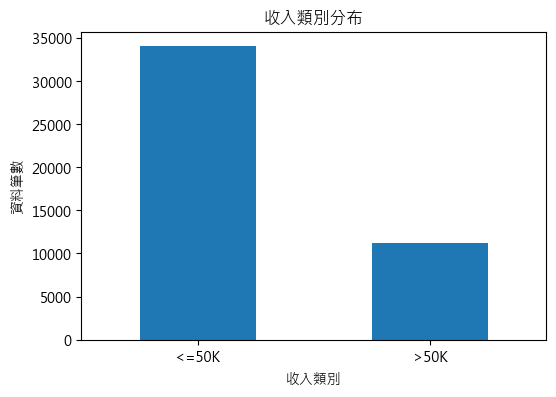

In [4]:

# 計算收入類別的筆數
income_counts = df_clean["income"].value_counts()

# 畫出長條圖
plt.figure(figsize=(6, 4))
income_counts.plot(kind="bar")
plt.title("收入類別分布")
plt.xlabel("收入類別")
plt.ylabel("資料筆數")
plt.xticks(rotation=0)
plt.show()



## 5. 建立特徵 X 與目標 y

在機器學習中，通常會把資料分成：

- `X`：特徵，也就是模型用來學習的輸入欄位
- `y`：目標，也就是模型要預測的答案

這裡我們會移除原本的 `income` 文字欄位與剛建立的 `income_label`，剩下的欄位作為特徵。


In [5]:

# 建立特徵 X
# income 是原本的文字答案欄位，income_label 是轉換後的答案欄位
# 這兩個欄位不能放進 X，否則模型會直接看到答案

X = df_clean.drop(columns=["income", "income_label"])

# 建立目標 y
y = df_clean["income_label"]

print("X 的大小：")
print(X.shape)

print("\ny 的大小：")
print(y.shape)

print("\nX 的前 5 筆資料：")
display(X.head())


X 的大小：
(45222, 14)

y 的大小：
(45222,)

X 的前 5 筆資料：


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States



## 6. 切分訓練集與測試集

訓練集用來讓模型學習；測試集用來檢查模型對新資料的表現。

這裡使用：

- 80% 作為訓練集
- 20% 作為測試集

`stratify=y` 會讓訓練集與測試集維持相近的類別比例。


In [6]:

# 切分訓練集與測試集

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

print("訓練集 X_train：", X_train.shape)
print("測試集 X_test：", X_test.shape)
print("訓練集 y_train：", y_train.shape)
print("測試集 y_test：", y_test.shape)


訓練集 X_train： (36177, 14)
測試集 X_test： (9045, 14)
訓練集 y_train： (36177,)
測試集 y_test： (9045,)



## 7. 類別型特徵轉換：One-Hot Encoding

羅吉斯迴歸需要數值型特徵，因此文字類別欄位必須先轉成數值。

這裡使用 `pd.get_dummies()` 做 One-Hot Encoding。

注意：

1. 先對訓練集做編碼
2. 再對測試集做編碼
3. 測試集欄位要對齊訓練集欄位

這樣可以避免訓練集與測試集欄位不一致。


In [7]:

# 將類別型特徵轉成 one-hot 欄位
# drop_first=True 可以減少重複資訊，也讓欄位數少一點

X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# 讓測試集欄位順序與訓練集完全一致
# 如果測試集中缺少某些訓練集欄位，就補 0
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print("編碼後的訓練集大小：")
print(X_train_encoded.shape)

print("\n編碼後的測試集大小：")
print(X_test_encoded.shape)

print("\n編碼後的前 5 個欄位名稱：")
print(X_train_encoded.columns[0:5])


編碼後的訓練集大小：
(36177, 96)

編碼後的測試集大小：
(9045, 96)

編碼後的前 5 個欄位名稱：
Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss'], dtype='str')



## 8. 特徵標準化

羅吉斯迴歸會透過最佳化方法尋找模型參數。

如果特徵尺度差異很大，例如：

- `age` 大約是幾十
- `fnlwgt` 可能是幾十萬
- one-hot 欄位只有 0 或 1

模型訓練可能會受到尺度影響，因此我們使用 `StandardScaler` 做標準化。

重要觀念：

- `scaler.fit()` 只能用訓練集
- 測試集只能用訓練集學到的 scaler 來 `transform()`
- 不能用測試集來 `fit()`，否則會造成資料洩漏


In [8]:

# 建立標準化工具
scaler = StandardScaler()

# 只能用訓練集 fit
scaler.fit(X_train_encoded)

# 使用同一個 scaler 轉換訓練集與測試集
X_train_scaled = scaler.transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print("標準化後訓練集大小：")
print(X_train_scaled.shape)

print("\n標準化後測試集大小：")
print(X_test_scaled.shape)


標準化後訓練集大小：
(36177, 96)

標準化後測試集大小：
(9045, 96)



## 9. 羅吉斯迴歸模型

羅吉斯迴歸雖然名稱裡有「迴歸」，但它常用於分類任務。

對二元分類而言，羅吉斯迴歸會把線性組合轉成 0 到 1 之間的機率：

$$
 p(y=1 \mid x) = \frac{1}{1 + e^{-z}}
$$

其中：

$$
 z = w_0 + w_1x_1 + w_2x_2 + \cdots + w_nx_n
$$

`C` 是正則化強度的倒數：

- `C` 越小：正則化越強，模型越簡單
- `C` 越大：正則化越弱，模型越容易貼近訓練資料

本作業先使用 `C=1.0`。


In [9]:

# 建立羅吉斯迴歸模型
# penalty="l2" 是預設常見正則化方式
# C=1.0 代表使用一般強度的正則化
# solver="liblinear" 適合二元分類與初學教學範例

model = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    max_iter=1000,
    random_state=0
)

# 訓練模型
model.fit(X_train_scaled, y_train)

print("模型訓練完成")


模型訓練完成



## 10. 評估分類器效能：F1-score 與混淆矩陣

教材中有多種評估指標。為了讓作業簡化，本作業只把 **F1-score** 作為主要指標。

F1-score 同時考慮：

- precision：預測為正類的人裡面，有多少是真的正類
- recall：真正的正類裡面，有多少被模型找出來

此外，我們會用混淆矩陣視覺化模型預測錯在哪裡。


測試集 F1-score：
0.667


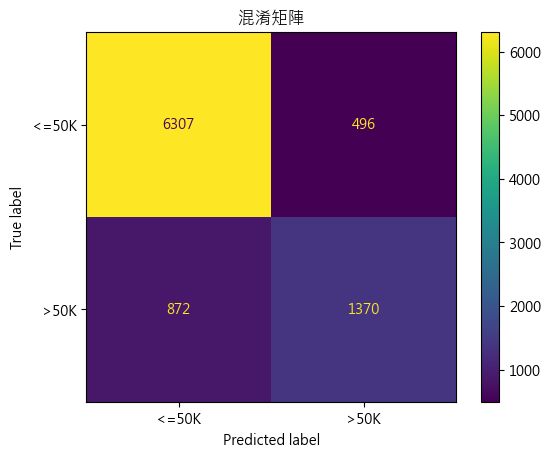

In [10]:

# 使用測試集進行預測

y_pred = model.predict(X_test_scaled)

# 計算 F1-score
# pos_label=1 代表我們關心的正類是 >50K
f1 = f1_score(y_test, y_pred, pos_label=1)

print("測試集 F1-score：")
print(round(f1, 4))

# 繪製混淆矩陣
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["<=50K", ">50K"]
)
plt.title("混淆矩陣")
plt.show()



## 11. 分類結果的可靠度：預測機率與決策分數

分類模型不只可以輸出最後類別，也可以輸出模型對分類結果的信心。

常見方法有兩種：

1. `predict_proba()`：輸出每個類別的預測機率
2. `decision_function()`：輸出樣本離決策邊界的距離分數

對羅吉斯迴歸來說：

- `predict_proba()` 越接近 1，代表模型越相信該樣本屬於 `>50K`
- `decision_function()` 大於 0 時，通常會被分類成正類 `>50K`
- `decision_function()` 越接近 0，代表樣本越接近分類邊界，模型越不確定


In [11]:

# 取得預測機率
proba = model.predict_proba(X_test_scaled)

# 取得 decision_function 分數
decision_scores = model.decision_function(X_test_scaled)

# 整理前 10 筆測試資料，方便觀察
preview = X_test.reset_index(drop=True).loc[0:9, ["age", "education", "hours-per-week"]]
preview["實際類別"] = y_test.reset_index(drop=True).loc[0:9]
preview["預測類別"] = pd.Series(y_pred).loc[0:9]
preview["預測為 >50K 的機率"] = pd.Series(proba[:, 1]).loc[0:9].round(3)
preview["decision_function 分數"] = pd.Series(decision_scores).loc[0:9].round(3)

display(preview)


,age,education,hours-per-week,實際類別,預測類別,預測為 >50K 的機率,decision_function 分數
0,19,HS-grad,25,0,0,0.003,-5.984
1,34,Bachelors,40,1,1,0.883,2.020
2,57,Masters,40,0,0,0.209,-1.330
3,29,11th,60,0,0,0.136,-1.845
4,45,HS-grad,40,0,0,0.018,-4.022
5,44,HS-grad,40,0,0,0.373,-0.519
6,27,HS-grad,40,0,0,0.151,-1.729
7,42,HS-grad,40,0,0,0.271,-0.991
8,19,9th,20,0,0,0.001,-6.604
9,43,Some-college,45,0,0,0.306,-0.819



## 12. 視覺化 sigmoid 函數

羅吉斯迴歸會使用 sigmoid 函數把任意實數轉成 0 到 1 之間的機率。

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

當：

- `z` 很大，sigmoid 會接近 1
- `z` 很小，sigmoid 會接近 0
- `z = 0`，sigmoid 等於 0.5


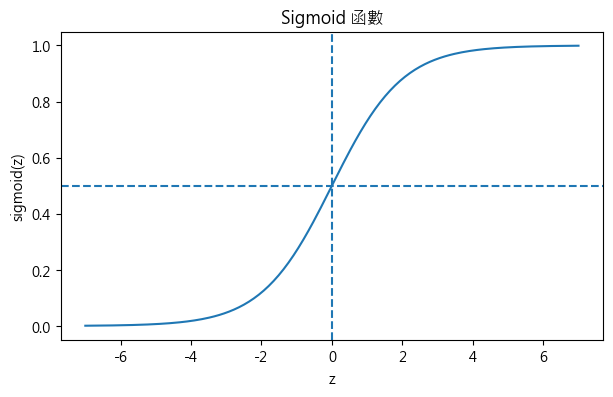

In [12]:

# 定義 sigmoid 函數

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

# 建立 z 的範圍
z = np.linspace(-7, 7, 200)

# 計算 sigmoid(z)
sigmoid_value = sigmoid(z)

# 畫圖
plt.figure(figsize=(7, 4))
plt.plot(z, sigmoid_value)
plt.axvline(0, linestyle="--")
plt.axhline(0.5, linestyle="--")
plt.title("Sigmoid 函數")
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.show()



## 13. 交叉驗證

只切一次訓練集與測試集，可能會受到切分方式影響。

交叉驗證會把資料分成多份，輪流把其中一份當驗證集，其餘當訓練集。

這裡使用 `StratifiedKFold`，讓每一折維持相近的類別比例。

注意：

因為本作業不使用 `Pipeline`，所以每一折都要在該折的訓練資料中重新做：

1. one-hot encoding
2. 標準化 fit
3. 模型訓練
4. 驗證集預測


In [13]:

# 建立 3-fold 交叉驗證
# n_splits=3 代表切成 3 份

skf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=0
)

cv_scores = []
fold_number = 1

for train_index, valid_index in skf.split(X, y):
    # 取出該折的訓練資料與驗證資料
    X_cv_train = X.iloc[train_index]
    X_cv_valid = X.iloc[valid_index]
    y_cv_train = y.iloc[train_index]
    y_cv_valid = y.iloc[valid_index]
    
    # one-hot encoding
    X_cv_train_encoded = pd.get_dummies(X_cv_train, drop_first=True)
    X_cv_valid_encoded = pd.get_dummies(X_cv_valid, drop_first=True)
    X_cv_valid_encoded = X_cv_valid_encoded.reindex(
        columns=X_cv_train_encoded.columns,
        fill_value=0
    )
    
    # 標準化
    scaler_cv = StandardScaler()
    scaler_cv.fit(X_cv_train_encoded)
    X_cv_train_scaled = scaler_cv.transform(X_cv_train_encoded)
    X_cv_valid_scaled = scaler_cv.transform(X_cv_valid_encoded)
    
    # 訓練模型
    model_cv = LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="liblinear",
        max_iter=1000,
        random_state=0
    )
    model_cv.fit(X_cv_train_scaled, y_cv_train)
    
    # 驗證集預測
    y_cv_pred = model_cv.predict(X_cv_valid_scaled)
    
    # 計算該折 F1-score
    fold_f1 = f1_score(y_cv_valid, y_cv_pred, pos_label=1)
    cv_scores.append(fold_f1)
    
    print("第", fold_number, "折 F1-score：", round(fold_f1, 4))
    fold_number = fold_number + 1

print("\n平均 F1-score：")
print(round(np.mean(cv_scores), 4))


第 1 折 F1-score： 0.667
第 2 折 F1-score： 0.6673
第 3 折 F1-score： 0.6555

平均 F1-score：
0.6633



## 14. 特徵重要性：使用羅吉斯迴歸係數觀察特徵影響

教材中提到隨機森林可以用 `feature_importances_` 查看特徵重要性。

本作業為了簡化，只使用一個模型：羅吉斯迴歸。

因此這裡改用羅吉斯迴歸的係數來觀察特徵影響：

- 係數為正：該特徵增加時，比較傾向預測為 `>50K`
- 係數為負：該特徵增加時，比較傾向預測為 `<=50K`
- 係數絕對值越大：該特徵對模型影響越大

注意：這裡的係數是「模型中的影響」，不一定代表真實世界的因果關係。


影響最大的前 15 個特徵：


,feature,coef,abs_coef
3,capital-gain,2.366025,2.366025
28,marital-status_Married-civ-spouse,1.151873,1.151873
2,educational-num,0.604083,0.604083
55,gender_Male,0.352121,0.352121
0,age,0.344584,0.344584
5,hours-per-week,0.344267,0.344267
39,occupation_Other-service,-0.312787,0.312787
4,capital-loss,0.271512,0.271512
9,workclass_Self-emp-not-inc,-0.261310,0.261310
50,relationship_Wife,0.244519,0.244519


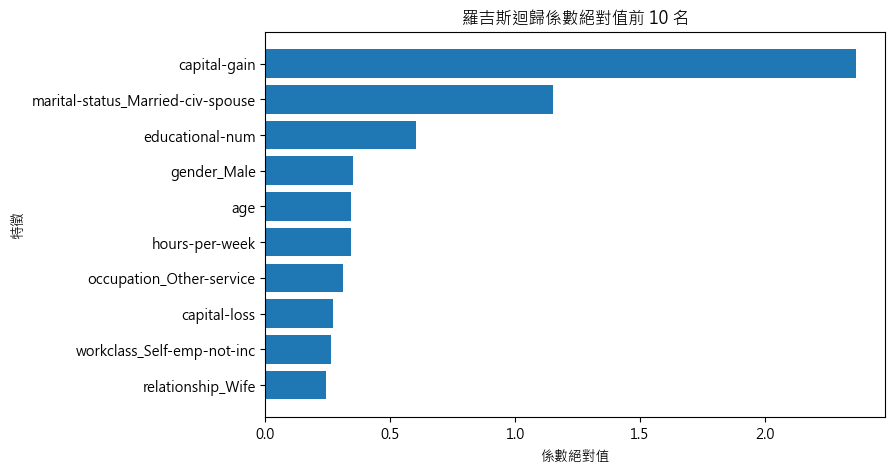

In [14]:

# 取出羅吉斯迴歸模型的係數
coef_values = model.coef_[0]

# 建立特徵重要性表格
feature_weight = pd.DataFrame()
feature_weight["feature"] = X_train_encoded.columns
feature_weight["coef"] = coef_values
feature_weight["abs_coef"] = np.abs(coef_values)

# 依照係數絕對值由大到小排序
feature_weight = feature_weight.sort_values("abs_coef", ascending=False)

print("影響最大的前 15 個特徵：")
display(feature_weight.head(15))

# 視覺化前 10 個重要特徵
top_10_features = feature_weight.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_10_features["feature"], top_10_features["abs_coef"])
plt.gca().invert_yaxis()
plt.title("羅吉斯迴歸係數絕對值前 10 名")
plt.xlabel("係數絕對值")
plt.ylabel("特徵")
plt.show()



## 15. 簡化版特徵選擇

教材中有使用模型選擇重要特徵的概念。

這裡使用簡化做法：

1. 根據羅吉斯迴歸係數絕對值排序
2. 選出前 10 個特徵
3. 只用這 10 個特徵重新訓練模型
4. 比較完整特徵模型與簡化特徵模型的 F1-score

這可以幫助同學理解：

- 特徵越多不一定越好
- 少量重要特徵有時也能得到不錯的結果
- 特徵選擇可以讓模型更容易解釋


In [15]:

# 選出係數絕對值前 10 名的特徵名稱
selected_features = feature_weight.head(10)["feature"]

print("選出的特徵：")
print(selected_features)

# 只保留選出的特徵
X_train_selected = X_train_encoded[selected_features]
X_test_selected = X_test_encoded[selected_features]

# 重新標準化
scaler_selected = StandardScaler()
scaler_selected.fit(X_train_selected)
X_train_selected_scaled = scaler_selected.transform(X_train_selected)
X_test_selected_scaled = scaler_selected.transform(X_test_selected)

# 使用相同設定重新訓練羅吉斯迴歸
model_selected = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    max_iter=1000,
    random_state=0
)
model_selected.fit(X_train_selected_scaled, y_train)

# 預測並計算 F1-score
y_pred_selected = model_selected.predict(X_test_selected_scaled)
f1_selected = f1_score(y_test, y_pred_selected, pos_label=1)

print("完整特徵模型 F1-score：", round(f1, 4))
print("前 10 個重要特徵模型 F1-score：", round(f1_selected, 4))


選出的特徵：
3                          capital-gain
28    marital-status_Married-civ-spouse
2                       educational-num
55                          gender_Male
0                                   age
5                        hours-per-week
39             occupation_Other-service
4                          capital-loss
9            workclass_Self-emp-not-inc
50                    relationship_Wife
Name: feature, dtype: str
完整特徵模型 F1-score： 0.667
前 10 個重要特徵模型 F1-score： 0.6448



## 16. 補充：決策樹的熵 Entropy

教材中的決策樹會提到 entropy 與 information gain。

Entropy 可以理解成「資料混亂程度」：

- 如果一個節點幾乎都是同一類，entropy 低
- 如果一個節點兩類混在一起，entropy 高

二元分類的 entropy 公式如下：

$$
Entropy = -p_1 \log_2(p_1) - p_0 \log_2(p_0)
$$

本作業不實作決策樹模型，但保留 entropy 的基本概念。


In [16]:

# 簡單計算 entropy
# 假設一個節點中有 9 筆正類、5 筆負類

import math

positive_count = 9
negative_count = 5
total_count = positive_count + negative_count

p_positive = positive_count / total_count
p_negative = negative_count / total_count

entropy = -(p_positive * math.log2(p_positive) + p_negative * math.log2(p_negative))

print("Entropy：")
print(round(entropy, 4))


Entropy：
0.9403



## 17. 教材中的其他分類模型：概念整理

`3.ipynb` 介紹了多種分類模型。為了讓作業不過度複雜，本作業只實作羅吉斯迴歸。

其他模型的核心概念整理如下：

| 模型 | 核心概念 | 本作業如何保留重點 |
|---|---|---|
| 羅吉斯迴歸 Logistic Regression | 用 sigmoid 把線性分數轉成機率 | 本作業主要實作模型 |
| 多元分類 OvR / OvO | 將多類別問題拆成多個二元分類問題 | Adult 是二元分類，因此以概念說明為主 |
| SVM | 找到能最大化 margin 的分類邊界 | 保留「需要標準化」與「分類邊界」概念 |
| RBF SVM | 用 kernel 處理非線性分類 | 保留 `C` 與 `gamma` 會影響模型複雜度的觀念 |
| Naive Bayes | 使用機率與條件獨立假設分類 | 保留「可用機率解釋分類」概念 |
| Decision Tree | 根據 entropy / information gain 切分資料 | 本作業保留 entropy 計算 |
| Random Forest | 多棵決策樹投票，降低單棵樹不穩定性 | 本作業用羅吉斯迴歸係數示範特徵重要性概念 |
| KNN | 根據距離最近的鄰居投票分類 | 本作業保留「距離型模型需要標準化」概念 |

如果要讓學生進一步練習，可以在完成本作業後，再請學生把模型換成 SVM、Decision Tree 或 KNN 觀察差異。



## 18. 作業問題

請根據上面的程式執行結果，回答以下問題。

### 問題 1：目標變數分布

`<=50K` 與 `>50K` 哪一類比較多？這樣的類別分布可能會對模型造成什麼影響？

### 問題 2：F1-score 與混淆矩陣

觀察混淆矩陣，模型比較常把哪一類預測錯？你認為可能原因是什麼？

### 問題 3：預測機率

找出一筆 `預測為 >50K 的機率` 接近 0.5 的資料。這代表模型對這筆資料比較確定，還是比較不確定？

### 問題 4：正則化參數 C

請把羅吉斯迴歸的 `C` 改成：

- `C=0.1`
- `C=10`

觀察 F1-score 是否改變，並說明你的觀察。

### 問題 5：特徵重要性

觀察係數絕對值前 10 名的特徵。你覺得哪些特徵合理？哪些特徵需要小心解釋？為什麼？

### 問題 6：簡化特徵模型

只使用前 10 個重要特徵後，F1-score 是否下降很多？這代表什麼？
